# Getting started

## What is a KPNN?

A knowledge-primed neural network (KPNN) uses prior knowledge encoded as a
graph to constrain the structure of a neural network. Instead of starting from
a fully generic architecture, the model structure is informed by known
relationships between named entities.

The figure below illustrates the general idea of KPNNs.

![KPNNs explained](../figures/KPNNs_explained.svg)

## What does `edge2torch` do?

`edge2torch` implements this idea as a graph-to-model compiler plus
model-to-interpretation bridge.

The figure below summarizes the overall `edge2torch` workflow.

<img src="../figures/graphical_abstract.svg"
     alt="Graphical abstract of edge2torch"
     style="width: 100%; max-width: 100%;">

This notebook shows the basic `edge2torch` workflow:

1. represent prior knowledge as an edgelist
2. compile the graph into a PyTorch model
3. use the compiled model like ordinary PyTorch
4. interpret the model back in biological space


## Installation

Install `edge2torch` from PyPI with:

```bash
pip install edge2torch
```

For optional `AnnData` support:

```bash
pip install "edge2torch[bio]"
```


## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from torch import nn

from edge2torch.compile_graph import compile_graph
from edge2torch.customize_model import customize_model
from edge2torch.interpret_model import interpret_model

In [2]:
sns.set_theme(style="whitegrid")

## Step 1: define a prior-knowledge graph

For v1, `edge2torch` expects an edgelist with two required columns:

- `source`
- `target`

Here we define a small feedforward biological graph with two clearly
separated branches:

- a **signal branch**, connected to informative input features
- a **noise branch**, connected to uninformative input features

This makes the later interpretation steps easier to understand: after
training, informative features and their connected hidden nodes should
receive stronger attributions than the uninformative branch.

A separate later section of this notebook shows how feedforward skip edges
are handled internally through pseudo nodes.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
            "tf_signal",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
        ],
        "target": [
            "tf_signal",
            "tf_signal",
            "tf_signal",
            "tf_noise",
            "tf_noise",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
            "output_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise
6,tf_signal,kinase_signal
7,tf_noise,kinase_noise
8,kinase_signal,output_1
9,kinase_noise,output_1


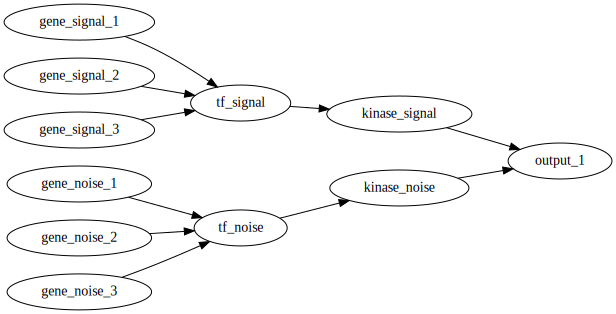

In [4]:
# Visualize the graph

dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
layer_1_nodes = ["tf_signal", "tf_noise"]
layer_2_nodes = ["kinase_signal", "kinase_noise"]
output_nodes = ["output_1"]

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in input_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_1_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_2_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in output_nodes:
        s.node(node, node)

for _, row in edgelist.iterrows():
    dot.edge(row["source"], row["target"])

dot

## Step 2: compile the graph

`compile_graph(...)` returns:

- a compiled PyTorch model
- a compilation artifact containing the metadata needed later for
  interpretation


In [5]:
model, artifact = compile_graph(
    edgelist=edgelist,
    backend="feedforward",
)

type(model), type(artifact)

[edge2torch] Note: Graph contains 11 node(s) and 10 edge(s).
[edge2torch] Note: Feedforward backend selected. Graph must be layerable.


(edge2torch.nn.model.EdgeModel, edge2torch.compile.artifact.CompileArtifact)

## Inspect the artifact

The artifact is the bridge between compilation and interpretation.


In [6]:
artifact.backend

'feedforward'

In [7]:
artifact.feature_names

['gene_noise_1',
 'gene_noise_2',
 'gene_noise_3',
 'gene_signal_1',
 'gene_signal_2',
 'gene_signal_3']

In [8]:
artifact.node_names_by_layer

{'layer_0': ['gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'],
 'layer_1': ['tf_noise', 'tf_signal'],
 'layer_2': ['kinase_noise', 'kinase_signal'],
 'layer_3': ['output_1']}

## Step 3: customize the compiled model

The compiled model is intentionally minimal. It defines the graph-derived
structural core, but it does not impose architectural choices such as
activation functions, dropout, or output heads.

For this binary classification example, we add:
- a ReLU activation
- a one-dimensional linear head that outputs a single logit

This keeps the model simple while making it suitable for classification
with standard PyTorch loss functions.

In [9]:
customized_model = customize_model(
    model=model,
    activation=nn.ReLU(),
    head=nn.Linear(1, 1),
)

customized_model

CustomizedEdgeModel(
  (base_model): EdgeModel(
    (blocks): ModuleList(
      (0-2): 3 x FeedforwardLayerBlock(
        (linear): MaskedLinear()
      )
    )
  )
  (activation): ReLU()
  (head): Linear(in_features=1, out_features=1, bias=True)
)

## Step 4: train the compiled and customized model in PyTorch

The customized model is still a normal PyTorch module. This means it can be
trained with ordinary PyTorch components such as loss functions, optimizers,
and training loops.

Below is a minimal training step that shows how the compiled structural core
and the added architectural components fit directly into a standard PyTorch
workflow.

In [10]:
# Simulate the training and test data
rng = np.random.default_rng(1)

informative_features = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]

noise_features = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]

all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )

    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )

    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)

    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )

    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]

    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")

    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)

x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

display(x_train_df.head())
display(y_train.head())
display(x_test_df.head())
display(y_test.head())

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,0.382930,-0.875721,-1.514319,0.287017,-0.578793,-0.876897
1,1.517455,1.217601,1.815758,0.163509,0.816011,-2.110056
2,0.245773,-0.746653,0.678740,0.878297,1.253826,-0.411778
3,1.760951,2.510922,3.001886,-0.288594,-1.136983,-0.619579
4,0.663658,1.972474,0.209167,0.759971,0.203371,1.658664


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,0.096989,-0.170139,0.267756,0.777494,-1.892990,-0.051819
1,0.840300,1.595801,2.247646,-0.166935,-0.075523,-0.681671
2,-0.046298,0.553205,0.538196,1.204293,-0.605907,-0.042248
3,1.802631,1.617305,3.093590,-1.421344,0.028217,-1.256497
4,0.855323,-1.541040,-0.419259,2.527698,0.303440,1.674191


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

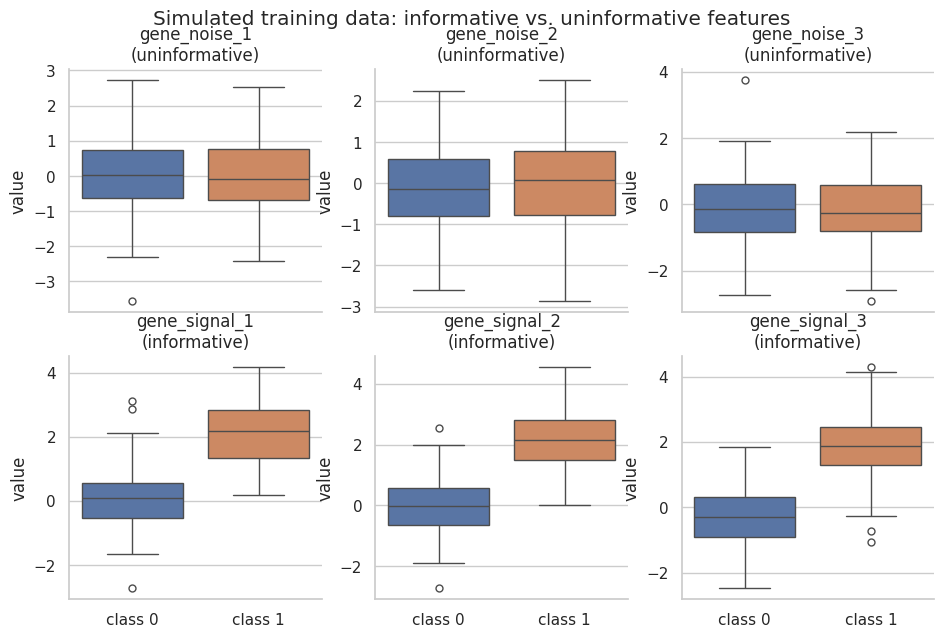

In [11]:
# Visualize the simulated training data

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = x_train_df.copy()
plot_df["label"] = y_train.values
plot_df["class"] = plot_df["label"].map({0: "class 0", 1: "class 1"})

long_df = plot_df.melt(
    id_vars=["label", "class"],
    value_vars=artifact.feature_names,
    var_name="feature",
    value_name="value",
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}

long_df["feature_type"] = long_df["feature"].map(feature_type_map)

g = sns.catplot(
    data=long_df,
    x="class",
    y="value",
    col="feature",
    col_wrap=3,
    hue="class",
    kind="box",
    sharey=False,
    height=3.2,
    aspect=1.0,
    legend=False,
)

g.fig.suptitle(
    "Simulated training data: informative vs. uninformative features",
    y=1.03,
)

for ax, feature in zip(g.axes.flat, artifact.feature_names):
    feature_type = feature_type_map[feature]
    ax.set_title(f"{feature}\n({feature_type})")
    ax.set_xlabel("")
    ax.set_ylabel("value")

plt.show()

Initial loss: 0.8055
Final loss:   0.2421


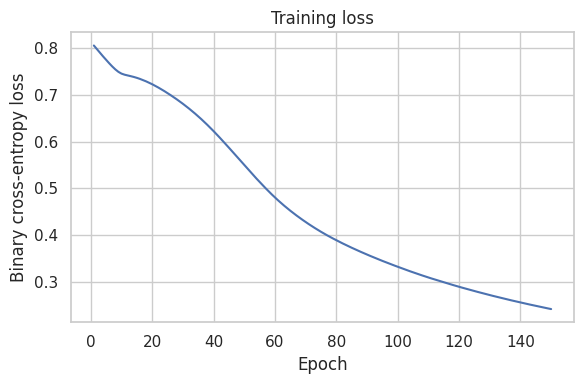

In [12]:
# Train the model with the simulated data

torch.manual_seed(1)

x_train = torch.tensor(
    x_train_df[artifact.feature_names].values,
    dtype=torch.float32,
)
y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    customized_model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []

customized_model.train()

for epoch in range(n_epochs):
    optimizer.zero_grad()

    logits = customized_model(x_train)
    loss = loss_fn(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Initial loss:", round(loss_history[0], 4))
print("Final loss:  ", round(loss_history[-1], 4))

plt.figure(figsize=(6, 4))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Step 5: feature-level interpretation

Feature-level interpretation maps attributions back to the input features.

For this example, we use:

- `target="features"`
- `method="integrated_gradients"`

Because the dataset was simulated, we know which features truly separate the
two classes: the `gene_signal_*` features were generated with different class
means, whereas the `gene_noise_*` features were not.

This gives us a useful sanity check for interpretation. The recovered feature
attributions do not need to match the simulated class mean differences exactly,
but the informative features should generally receive larger attribution
magnitudes than the uninformative ones.

In [13]:
feature_attr = interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="features",
    method="integrated_gradients",
)

feature_attr.head()

[edge2torch] Finished interpretation with method 'integrated_gradients' for target 'features'.


,gene_noise_1,gene_noise_2,gene_noise_3,gene_signal_1,gene_signal_2,gene_signal_3
0,-0.231982,-0.324767,0.006538,0.161795,-0.310777,0.518621
1,0.033987,-0.008841,0.058688,0.956496,1.988975,2.970589
2,-0.359327,-0.103951,0.005331,-0.077234,1.010489,1.042439
3,0.198860,0.002270,0.074340,1.410074,1.385252,2.809725
4,-0.754193,0.052059,-0.211240,1.426836,-2.814880,-0.812067


In [14]:
# Summarize feature attributions and compare them to the simulated signal

class_mean_diff = (
    x_test_df.loc[y_test == 1].mean() - x_test_df.loc[y_test == 0].mean()
)

feature_summary = pd.DataFrame(
    {
        "feature": artifact.feature_names,
        "abs_class_mean_difference": (
            class_mean_diff.abs().reindex(artifact.feature_names).values
        ),
        "mean_abs_attribution": (
            feature_attr.abs()
            .mean(axis=0)
            .reindex(artifact.feature_names)
            .values
        ),
        "mean_signed_attribution": (
            feature_attr.mean(axis=0).reindex(artifact.feature_names).values
        ),
    }
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}

feature_summary["feature_type"] = feature_summary["feature"].map(
    feature_type_map
)

feature_summary

,feature,abs_class_mean_difference,mean_abs_attribution,mean_signed_attribution,feature_type
0,gene_noise_1,0.094806,0.190793,-0.027428,uninformative
1,gene_noise_2,0.319823,0.116552,-0.005551,uninformative
2,gene_noise_3,0.204747,0.082046,-0.007403,uninformative
3,gene_signal_1,2.111796,1.630867,0.724326,informative
4,gene_signal_2,2.164730,1.792717,0.911815,informative
5,gene_signal_3,2.159934,1.962626,1.044858,informative


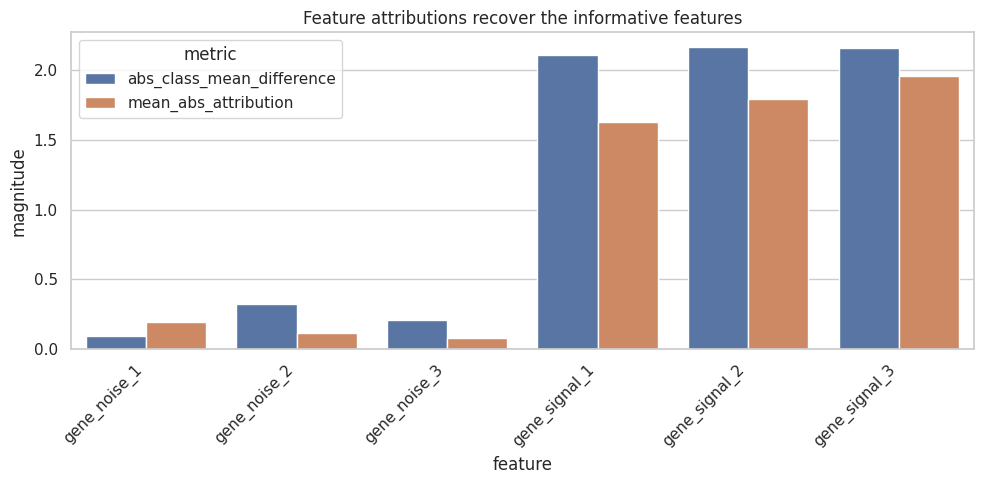

In [15]:
# Plot recovered attributions against the true simulated signal

plot_df = feature_summary.melt(
    id_vars=["feature", "feature_type"],
    value_vars=[
        "abs_class_mean_difference",
        "mean_abs_attribution",
    ],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="feature",
    y="value",
    hue="metric",
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("feature")
plt.ylabel("magnitude")
plt.title("Feature attributions recover the informative features")
plt.tight_layout()
plt.show()

## Step 6: node-level interpretation

Node-level interpretation maps attribution scores back to the internal nodes of
the compiled graph.

For this example, we use:

- `target="nodes"`
- `method="layer_conductance"`

This is often the most interesting interpretation level, because it helps show
which hidden biological entities in the network carry signal for the task.

The returned object is a dictionary:

- keys = layer names such as `"layer_1"` or `"layer_2"`
- values = pandas DataFrames
  - rows = test examples
  - columns = node names in that layer

Because this dataset was simulated with informative and uninformative feature
groups, we expect nodes on the informative branch of the graph to tend to show
larger attribution magnitudes than nodes on branches driven mainly by noise.

Internal pseudo nodes are automatically hidden from the returned results.

In [16]:
node_attr = interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="layer_conductance",
)

list(node_attr.keys())

[edge2torch] Finished interpretation with method 'layer_conductance' for target 'nodes'.


['layer_1', 'layer_2', 'layer_3']

The layer-wise node attribution tables can be inspected directly.

In [17]:
for layer_name, layer_df in node_attr.items():
    print(layer_name)
    display(layer_df.head())

layer_1


,tf_noise,tf_signal
0,-0.549611,0.369236
1,0.086804,6.125668
2,-0.457448,1.973541
3,0.293414,5.970145
4,-0.912379,-2.197711


layer_2


,kinase_noise,kinase_signal
0,-0.549611,0.369236
1,0.086804,6.125668
2,-0.457448,1.973541
3,0.293414,5.970145
4,-0.912379,-2.197711


layer_3


,output_1
0,-0.180376
1,6.212472
2,1.516093
3,6.263559
4,-3.110090


To make the node-level results easier to interpret, we now summarize the
attributions across the test set.

For each node, we compute:

- the mean attribution
- the mean absolute attribution

The mean absolute attribution is often especially useful, because it reflects
overall importance even when positive and negative values cancel out on average.

In [18]:
node_summary_frames = []

for layer_name, layer_df in node_attr.items():
    layer_summary = pd.DataFrame(
        {
            "layer": layer_name,
            "node": layer_df.columns,
            "mean_attribution": layer_df.mean(axis=0).values,
            "mean_abs_attribution": layer_df.abs().mean(axis=0).values,
        }
    )
    node_summary_frames.append(layer_summary)

node_summary = (
    pd.concat(node_summary_frames, ignore_index=True)
    .sort_values(
        ["layer", "mean_abs_attribution"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

node_summary

,layer,node,mean_attribution,mean_abs_attribution
0,layer_1,tf_signal,2.762850,4.523756
1,layer_1,tf_noise,-0.040068,0.216654
2,layer_2,kinase_signal,2.762849,4.523756
3,layer_2,kinase_noise,-0.040068,0.216654
4,layer_3,output_1,2.722781,4.530855


The following plot shows the mean absolute attribution for each internal node
across the test set.

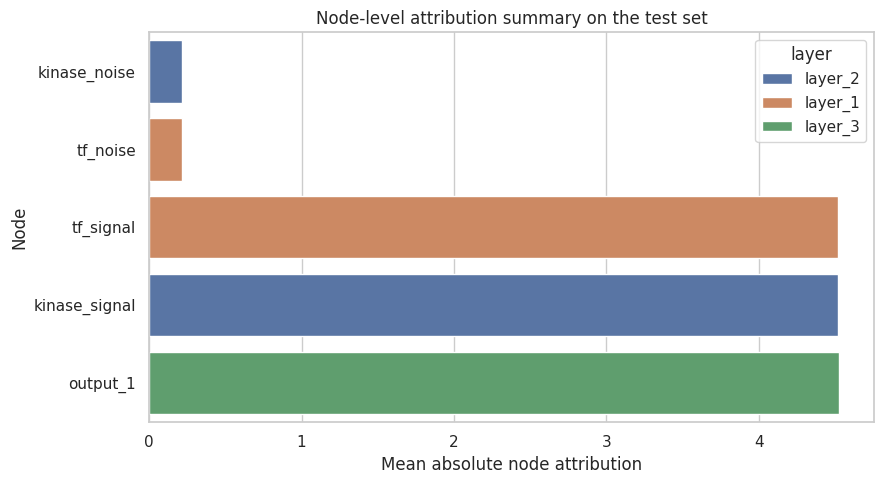

In [19]:
plot_df = node_summary.sort_values(
    "mean_abs_attribution",
    ascending=True,
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x="mean_abs_attribution",
    y="node",
    hue="layer",
    dodge=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Node-level attribution summary on the test set")
plt.tight_layout()
plt.show()